# 07 Evaluation and Analysis

This notebook evaluates the validation-selected checkpoint using the current test pipeline from `src/evaluate.py`.

Current evaluation behavior:

- loads `.keras` first, then `.h5` fallback if needed
- evaluates on saved `features/X_test.npy` and `features/y_test.npy`
- writes classification report, confusion matrix, per-class F1, confidence histogram, and misclassification CSV
- keeps the test set separate from model selection
        

In [1]:
from pathlib import Path
import json
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "config.yaml").exists() and (candidate / "src").exists():
        # if (candidate / "config.yaml").exists() and (candidate / "src").exists():
        # if (candidate / "configDeltaMFCC.yaml").exists() and (candidate / "src").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing config.yaml and src/")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.evaluate import EMOTION_NAMES, run_evaluation
from src.utils import load_config

warnings.filterwarnings("ignore")

config = load_config(PROJECT_ROOT / "config.yaml")
# config = load_config(PROJECT_ROOT / "configDeltaMFCC.yaml")
paths = config["paths"]
outputs_dir = Path(paths["outputs_dir"])
models_dir = Path(paths["models_dir"])
features_dir = Path(paths["features_dir"])
        

In [2]:
metrics = run_evaluation(config)
display(pd.DataFrame([metrics]))
        

2026-03-23 22:40:54 | INFO | ser.evaluate | Accuracy=0.8056 | Precision=0.8083 | Recall=0.8056 | F1=0.8060


,accuracy,macro_precision,macro_recall,macro_f1,test_samples
0,0.805556,0.808328,0.805556,0.80596,180


In [3]:
classification_report_path = outputs_dir / "classification_report.txt"
evaluation_report_path = outputs_dir / "evaluation_report.md"
misclassifications_path = outputs_dir / "misclassifications.csv"
confusion_values_path = outputs_dir / "confusion_matrix_values.csv"
training_summary_path = models_dir / "training_summary.json"

report_text = classification_report_path.read_text(encoding="utf-8")
display(Markdown("```text\n" + report_text + "\n```"))

if evaluation_report_path.exists():
    display(Markdown(evaluation_report_path.read_text(encoding="utf-8")))

if training_summary_path.exists():
    training_summary = json.loads(training_summary_path.read_text(encoding="utf-8"))
    display(pd.DataFrame([training_summary]))
        

```text
              precision    recall  f1-score   support

      Netral     0.8857    0.8611    0.8732        36
      Senang     0.8750    0.7778    0.8235        36
    Terkejut     0.7895    0.8333    0.8108        36
       Jijik     0.7222    0.7222    0.7222        36
      Kecewa     0.7692    0.8333    0.8000        36

    accuracy                         0.8056       180
   macro avg     0.8083    0.8056    0.8060       180
weighted avg     0.8083    0.8056    0.8060       180

```

# SER Evaluation Report

## Dataset
- Training: 840 samples (28 actors, on-the-fly augmentation)
- Validation: 180 samples (6 actors, no augmentation)
- Testing: 180 samples (6 actors, no augmentation)

## Metrics
- Accuracy: 0.8056
- Macro Precision: 0.8083
- Macro Recall: 0.8056
- Macro F1: 0.8060

## Notes
- Augmentation only on train via tf.data.
- Validation/test remain unaugmented.


,best_epoch,best_val_macro_f1_observed,best_val_accuracy_observed,restored_val_accuracy,restored_val_macro_precision,restored_val_macro_recall,restored_val_macro_f1,feature_dim,max_frames
0,60,0.744877,0.75,0.75,0.753043,0.75,0.744877,120,119


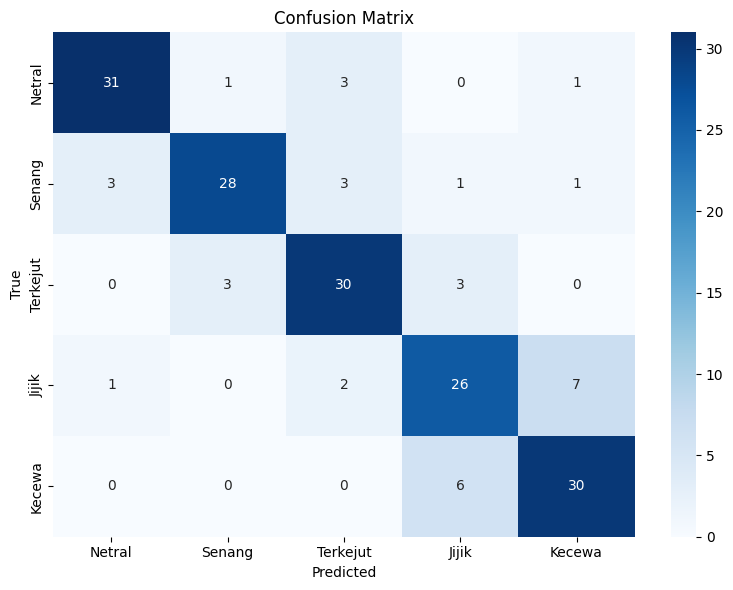

Total misclassifications: 35


,index,true_label,pred_label,confidence
0,20,Jijik,Kecewa,0.576762
1,42,Terkejut,Senang,0.899750
2,57,Kecewa,Jijik,0.896932
3,58,Kecewa,Jijik,0.819100
4,59,Kecewa,Jijik,0.833905
5,62,Netral,Kecewa,0.590264
6,63,Netral,Terkejut,0.992090
7,64,Netral,Terkejut,0.614445
8,65,Netral,Terkejut,0.829096
9,67,Senang,Terkejut,0.926571


In [4]:
cm = np.loadtxt(confusion_values_path, delimiter=",", dtype=int)
mis_df = pd.read_csv(misclassifications_path)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=EMOTION_NAMES,
    yticklabels=EMOTION_NAMES,
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

print("Total misclassifications:", len(mis_df))
display(mis_df.head(20))
        

In [5]:
confusions = []
for true_idx, true_name in enumerate(EMOTION_NAMES):
    for pred_idx, pred_name in enumerate(EMOTION_NAMES):
        if true_idx == pred_idx:
            continue
        count = int(cm[true_idx, pred_idx])
        if count > 0:
            confusions.append({
                "true_label": true_name,
                "pred_label": pred_name,
                "count": count,
            })

confusions_df = pd.DataFrame(confusions).sort_values(["count", "true_label", "pred_label"], ascending=[False, True, True])
display(confusions_df.head(10))
        

,true_label,pred_label,count
11,Jijik,Kecewa,7
12,Kecewa,Jijik,6
1,Netral,Terkejut,3
3,Senang,Netral,3
4,Senang,Terkejut,3
8,Terkejut,Jijik,3
7,Terkejut,Senang,3
10,Jijik,Terkejut,2
9,Jijik,Netral,1
2,Netral,Kecewa,1


In [6]:
per_class_correct = cm.diagonal()
per_class_total = cm.sum(axis=1)
per_class_accuracy = per_class_correct / np.maximum(per_class_total, 1)

class_summary = pd.DataFrame(
    {
        "emotion": EMOTION_NAMES,
        "correct": per_class_correct,
        "total": per_class_total,
        "class_accuracy": np.round(per_class_accuracy, 4),
    }
)
display(class_summary)
        

,emotion,correct,total,class_accuracy
0,Netral,31,36,0.8611
1,Senang,28,36,0.7778
2,Terkejut,30,36,0.8333
3,Jijik,26,36,0.7222
4,Kecewa,30,36,0.8333


## Interpretation

This notebook is now synchronized with the current evaluation implementation:

- it uses the checkpoint saved by validation macro F1
- it evaluates only on the held-out test feature tensors
- the confusion analysis and misclassification table come from the same artifacts written by `src.evaluate.run_evaluation()`

If you retrain the model in notebook 06, rerun this notebook to refresh all evaluation outputs.
        